# 02 — Exploratory Data Analysis

**Project:** `ecommerce-delivery-delay-prediction`  
**Phase:** 2 — Exploratory Data Analysis

## Goal

Explore patterns associated with late delivery while respecting the prediction point at `order_approved_at`.

The notebook focuses on:

- target imbalance;
- delivery-delay behavior;
- temporal patterns;
- customer geography;
- order characteristics;
- product characteristics;
- payment behavior;
- seller geography;
- customer–seller distance;
- candidate predictive signals;
- leakage risks.

> No model training is performed in this notebook.

## Modeling grain

The invariant throughout this notebook is:

**1 row = 1 order**

Any one-to-many raw table must be aggregated to order level before being merged into the EDA modeling table.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Project paths

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate

    raise FileNotFoundError(
        "Không tìm thấy project root chứa data/raw."
    )


PROJECT_ROOT = find_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS_DIR = PROJECT_ROOT / "reports" / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("INTERIM_DIR:", INTERIM_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: /home/namdp/Documents/Projects/ecommerce-delivery-delay-prediction
RAW_DIR: /home/namdp/Documents/Projects/ecommerce-delivery-delay-prediction/data/raw
INTERIM_DIR: /home/namdp/Documents/Projects/ecommerce-delivery-delay-prediction/data/interim
FIGURES_DIR: /home/namdp/Documents/Projects/ecommerce-delivery-delay-prediction/reports/figures


# 3. Load Final Modeling Population

`orders_cleaned.parquet` được tạo từ notebook `01_target_and_cleaning.ipynb` và là source of truth cho modeling population.

In [3]:
orders = pd.read_parquet(
    INTERIM_DIR / "orders_cleaned.parquet"
)

print("Shape:", orders.shape)
display(orders.head())

Shape: (96450, 10)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,late_delivery,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0,-7.1075
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,0,-5.3557
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0,-17.2455
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0,-12.9801
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,0,-9.2382


In [4]:
assert orders["order_id"].is_unique
assert orders["late_delivery"].isin([0, 1]).all()
assert orders["order_status"].eq("delivered").all()

assert not (
    orders["order_estimated_delivery_date"]
    <
    orders["order_approved_at"]
).any()

print(
    f"✓ Final modeling population loaded: "
    f"{len(orders):,} unique orders."
)


✓ Final modeling population loaded: 96,450 unique orders.


## 3.1 Modeling date range

In [5]:
date_summary = pd.Series(
    {
        "first_purchase": orders["order_purchase_timestamp"].min(),
        "last_purchase": orders["order_purchase_timestamp"].max(),
        "first_approval": orders["order_approved_at"].min(),
        "last_approval": orders["order_approved_at"].max(),
    },
    name="value",
)

display(date_summary.to_frame())

,value
first_purchase,2016-09-15 12:16:38
last_purchase,2018-08-29 15:00:37
first_approval,2016-09-15 12:16:38
last_approval,2018-08-29 15:10:26


# 4. Load Relational Tables

Reviews are intentionally excluded from feature-oriented EDA because review information is created after the prediction point and would introduce leakage.

In [6]:
customers = pd.read_csv(
    RAW_DIR / "olist_customers_dataset.csv"
)

order_items = pd.read_csv(
    RAW_DIR / "olist_order_items_dataset.csv"
)

products = pd.read_csv(
    RAW_DIR / "olist_products_dataset.csv"
)

sellers = pd.read_csv(
    RAW_DIR / "olist_sellers_dataset.csv"
)

payments = pd.read_csv(
    RAW_DIR / "olist_order_payments_dataset.csv"
)

geolocation = pd.read_csv(
    RAW_DIR / "olist_geolocation_dataset.csv"
)

category_translation = pd.read_csv(
    RAW_DIR / "product_category_name_translation.csv"
)

print("✓ Relational tables loaded.")

✓ Relational tables loaded.


# 5. Target Distribution

In [7]:
target_summary = (
    orders["late_delivery"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

target_summary["pct"] = (
    target_summary["count"]
    / len(orders)
    * 100
)

target_summary.index = target_summary.index.map(
    {
        0: "on_time",
        1: "late",
    }
)

display(target_summary)

,count,pct
late_delivery,,
on_time,88627,91.8891
late,7823,8.1109


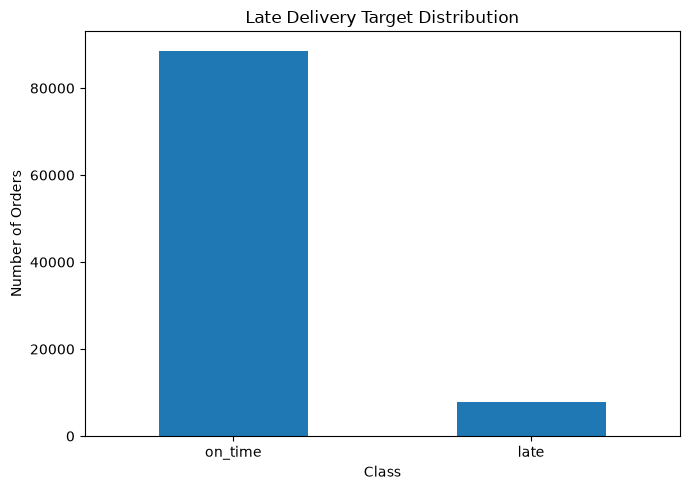

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

target_summary["count"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Late Delivery Target Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Orders")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_target_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Observation

The target is substantially imbalanced. Late deliveries represent only a minority of the finalized modeling population.

This means accuracy alone will not be an appropriate primary metric because a naive majority-class classifier can already achieve high accuracy.

# 6. Delivery Delay Analysis

In [9]:
display(
    orders["delivery_delay_days"]
    .describe()
    .to_frame()
)

,delivery_delay_days
count,"96,450.0000"
mean,-11.1774
std,10.1839
min,-146.0161
25%,-16.2438
50%,-11.9460
75%,-6.3901
max,188.9751


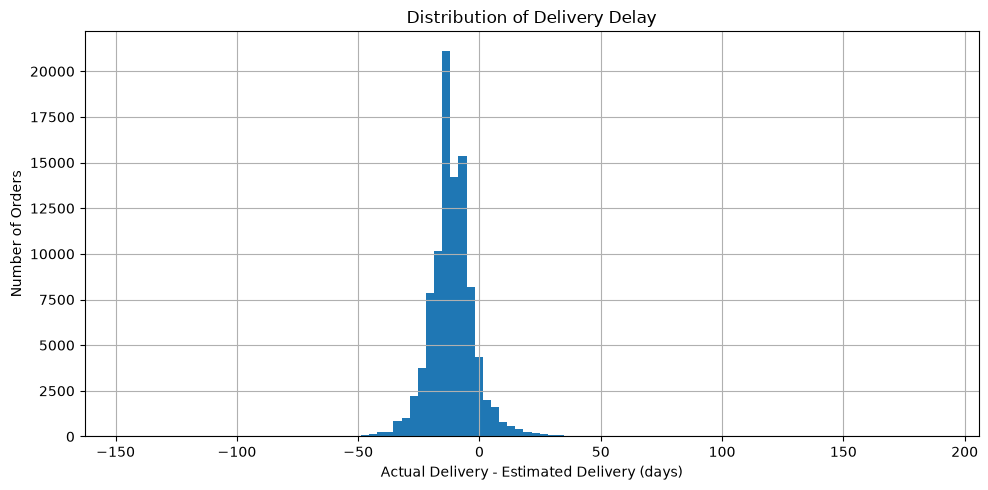

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

orders["delivery_delay_days"].hist(
    bins=100,
    ax=ax,
)

ax.set_title("Distribution of Delivery Delay")
ax.set_xlabel("Actual Delivery - Estimated Delivery (days)")
ax.set_ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "02_delivery_delay_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 6.1 Zoomed delivery-delay distribution

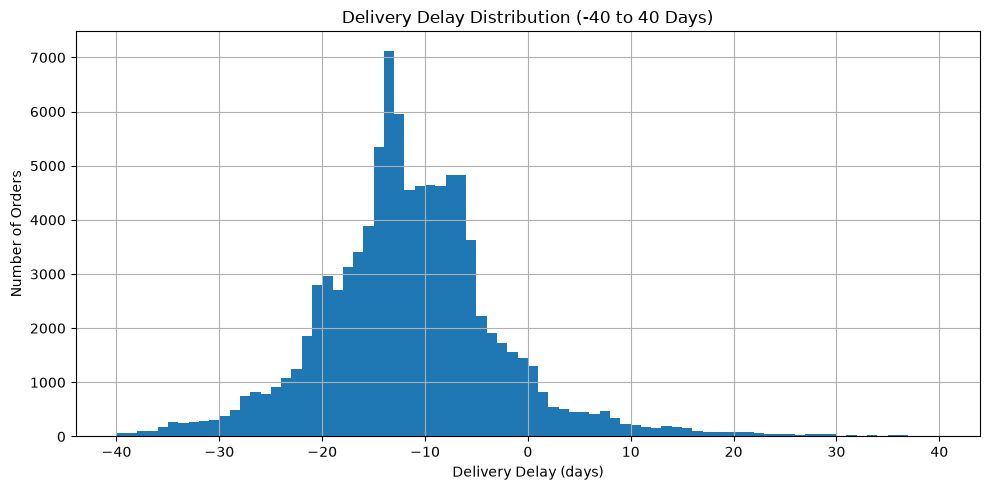

In [11]:
delay_zoom = orders[
    orders["delivery_delay_days"].between(-40, 40)
]

fig, ax = plt.subplots(figsize=(10, 5))

delay_zoom["delivery_delay_days"].hist(
    bins=80,
    ax=ax,
)

ax.set_title("Delivery Delay Distribution (-40 to 40 Days)")
ax.set_xlabel("Delivery Delay (days)")
ax.set_ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "03_delivery_delay_zoom.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 6.2 Late-order severity

In [12]:
late_orders = orders[
    orders["late_delivery"] == 1
].copy()

late_delay_summary = (
    late_orders["delivery_delay_days"]
    .describe()
    .to_frame()
)

display(late_delay_summary)

,delivery_delay_days
count,"7,823.0000"
mean,9.5544
std,13.9545
min,0.0025
25%,1.8673
50%,5.8096
75%,11.8225
max,188.9751


`delivery_delay_days` is **analysis-only** because it uses the actual customer delivery timestamp.

It must never be included in the model feature matrix.

# 7. Temporal EDA

In [13]:
eda_orders = orders.copy()

eda_orders["purchase_year"] = (
    eda_orders["order_purchase_timestamp"].dt.year
)

eda_orders["purchase_month"] = (
    eda_orders["order_purchase_timestamp"].dt.to_period("M")
)

eda_orders["purchase_weekday"] = (
    eda_orders["order_purchase_timestamp"].dt.day_name()
)

eda_orders["purchase_hour"] = (
    eda_orders["order_purchase_timestamp"].dt.hour
)

eda_orders["purchase_is_weekend"] = (
    eda_orders["order_purchase_timestamp"].dt.dayofweek >= 5
).astype("int8")

## 7.1 Late rate over time

In [14]:
monthly_late_rate = (
    eda_orders
    .groupby("purchase_month")
    ["late_delivery"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
)

display(monthly_late_rate)

,orders,late_rate
purchase_month,,
2016-09,1,1.0000
2016-10,265,0.0113
2016-12,1,0.0000
2017-01,748,0.0307
2017-02,1641,0.0323
2017-03,2546,0.0558
2017-04,2303,0.0786
2017-05,3545,0.0361
2017-06,3135,0.0386


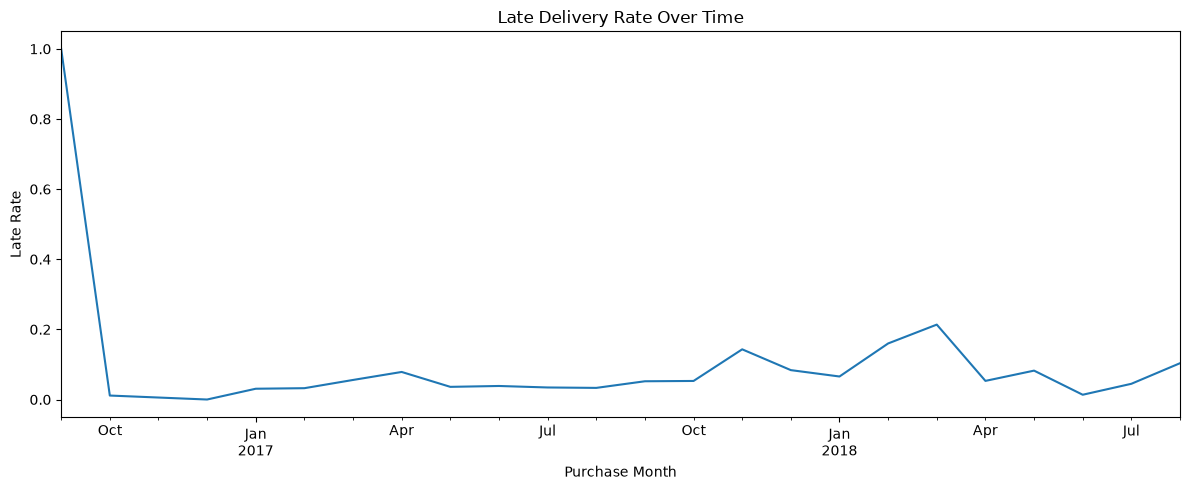

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

monthly_late_rate["late_rate"].plot(
    ax=ax,
)

ax.set_title("Late Delivery Rate Over Time")
ax.set_xlabel("Purchase Month")
ax.set_ylabel("Late Rate")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_monthly_late_rate.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

Look for:

- seasonality;
- unusual operational periods;
- possible concept drift;
- changes in late-delivery prevalence over time.

Temporal variation is also one reason chronological validation will be preferred later.

## 7.2 Late rate by weekday

In [16]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_late_rate = (
    eda_orders
    .groupby("purchase_weekday")
    ["late_delivery"]
    .agg(["count", "mean"])
    .reindex(weekday_order)
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
)

display(weekday_late_rate)

,orders,late_rate
purchase_weekday,,
Monday,15700,0.0905
Tuesday,15502,0.0849
Wednesday,15074,0.0780
Thursday,14317,0.0756
Friday,13680,0.0845
Saturday,10546,0.0760
Sunday,11631,0.0749


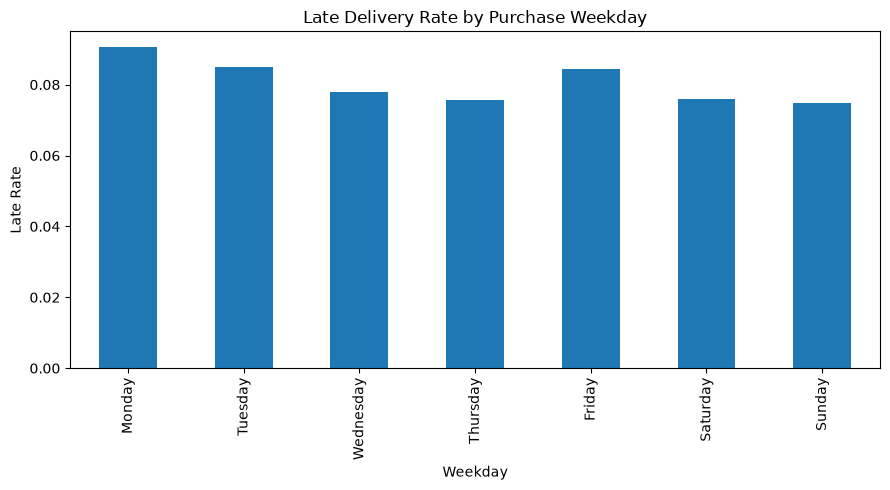

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

weekday_late_rate["late_rate"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Late Delivery Rate by Purchase Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Late Rate")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "05_weekday_late_rate.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 7.3 Late rate by purchase hour

In [18]:
hourly_late_rate = (
    eda_orders
    .groupby("purchase_hour")
    ["late_delivery"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
)

display(hourly_late_rate)

,orders,late_rate
purchase_hour,,
0,2321,0.0900
1,1132,0.0839
2,496,0.0706
3,259,0.0579
4,203,0.0542
5,182,0.0659
6,477,0.0692
7,1199,0.0784
8,2907,0.0746


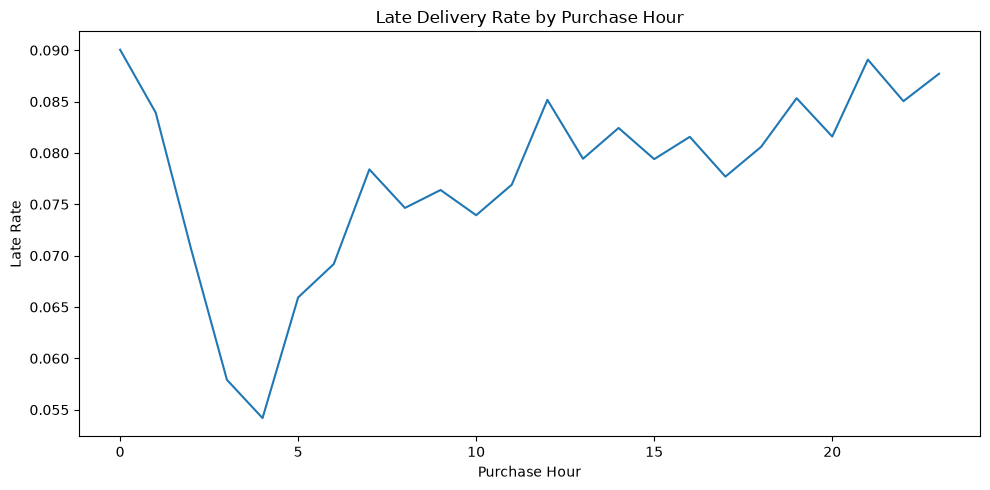

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

hourly_late_rate["late_rate"].plot(
    ax=ax,
)

ax.set_title("Late Delivery Rate by Purchase Hour")
ax.set_xlabel("Purchase Hour")
ax.set_ylabel("Late Rate")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "06_hourly_late_rate.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# 8. Promised Delivery Window

`order_estimated_delivery_date` and `order_approved_at` are known at the prediction point, so their difference is a valid candidate feature.

In [20]:
eda_orders["promised_delivery_days"] = (
    eda_orders["order_estimated_delivery_date"]
    - eda_orders["order_approved_at"]
).dt.total_seconds() / 86_400

display(
    eda_orders["promised_delivery_days"]
    .describe()
    .to_frame()
)

,promised_delivery_days
count,"96,450.0000"
mean,23.3081
std,8.7628
min,0.0205
25%,17.9062
50%,22.6700
75%,28.0676
max,153.5760


## 8.1 Promised-window data-quality validation

The upstream cleaning notebook excludes any row where:

`order_estimated_delivery_date < order_approved_at`

Therefore the cleaned EDA population must have no negative promised-delivery window.

In [21]:
invalid_promised_window = (
    eda_orders["order_estimated_delivery_date"]
    <
    eda_orders["order_approved_at"]
)

print(
    "Invalid promised delivery windows in cleaned data:",
    int(invalid_promised_window.sum()),
)

assert invalid_promised_window.sum() == 0
assert (eda_orders["promised_delivery_days"] >= 0).all()

print("✓ Promised delivery window validation passed.")

Invalid promised delivery windows in cleaned data: 0
✓ Promised delivery window validation passed.


In [22]:
promised_by_target = (
    eda_orders
    .groupby("late_delivery")
    ["promised_delivery_days"]
    .describe()
)

display(promised_by_target)

,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",23.4709,8.8094,0.0205,18.0102,22.8563,28.2200,153.5760
1,"7,823.0000",21.4641,7.9890,0.3113,17.3181,21.5614,26.3365,68.6906


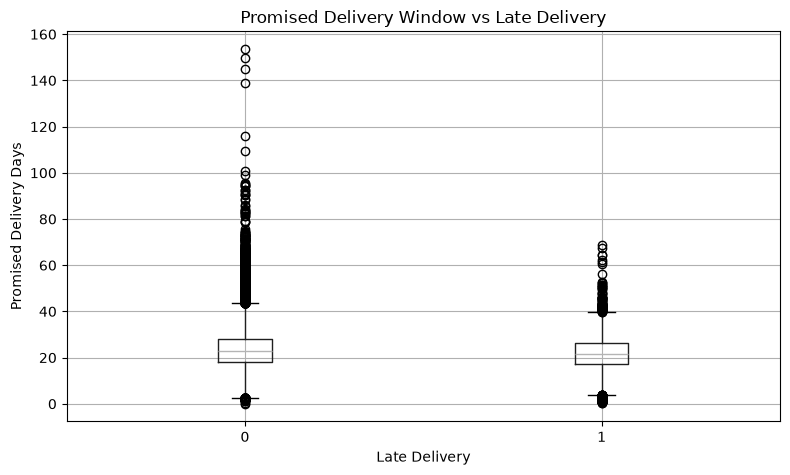

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

eda_orders.boxplot(
    column="promised_delivery_days",
    by="late_delivery",
    ax=ax,
)

ax.set_title("Promised Delivery Window vs Late Delivery")
ax.set_xlabel("Late Delivery")
ax.set_ylabel("Promised Delivery Days")

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "07_promised_delivery_window.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# 9. Customer Geography EDA

In [24]:
customer_orders = eda_orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="one_to_one",
)

assert len(customer_orders) == len(eda_orders)
assert customer_orders["order_id"].is_unique

print("✓ Customer join preserved order-level grain.")

✓ Customer join preserved order-level grain.


## 9.1 Late rate by customer state

In [25]:
customer_state_summary = (
    customer_orders
    .groupby("customer_state")
    ["late_delivery"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
    .sort_values(
        ["late_rate", "orders"],
        ascending=[False, False],
    )
)

display(customer_state_summary)

,orders,late_rate
customer_state,,
AL,397,0.2393
MA,716,0.1969
PI,476,0.1597
CE,1278,0.1534
SE,335,0.1522
BA,3256,0.1404
RJ,12348,0.1348
TO,274,0.1277
PA,946,0.1237


## 9.2 Customer states with sufficient sample size

In [26]:
customer_state_reliable = (
    customer_state_summary[
        customer_state_summary["orders"] >= 100
    ]
    .sort_values(
        "late_rate",
        ascending=False,
    )
)

display(customer_state_reliable)

,orders,late_rate
customer_state,,
AL,397,0.2393
MA,716,0.1969
PI,476,0.1597
CE,1278,0.1534
SE,335,0.1522
BA,3256,0.1404
RJ,12348,0.1348
TO,274,0.1277
PA,946,0.1237


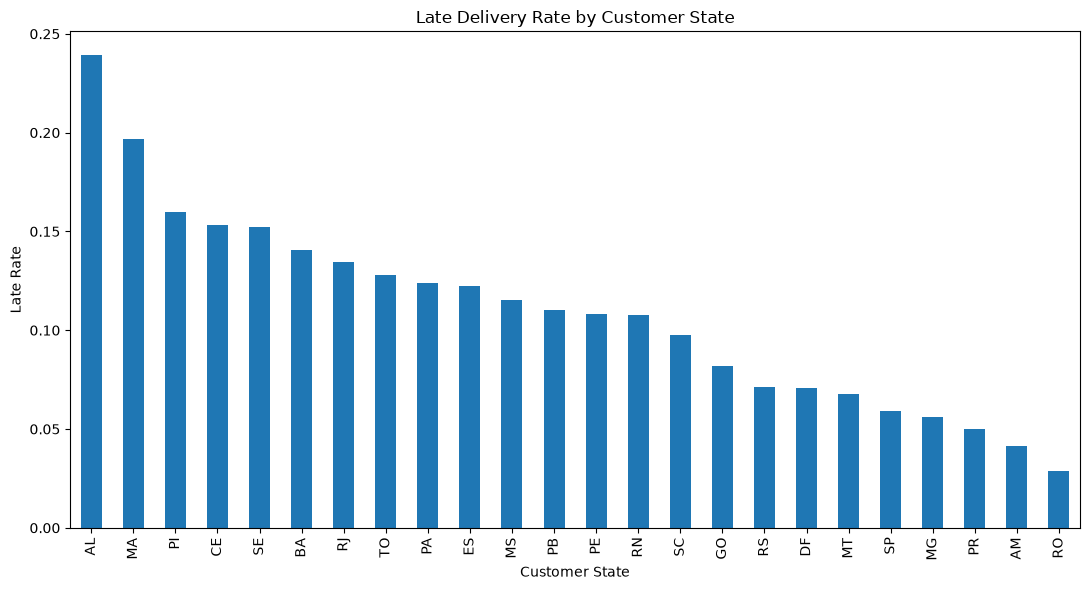

In [27]:
fig, ax = plt.subplots(figsize=(11, 6))

customer_state_reliable["late_rate"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Late Delivery Rate by Customer State")
ax.set_xlabel("Customer State")
ax.set_ylabel("Late Rate")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "08_customer_state_late_rate.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

Avoid strong conclusions from very small state-level samples. Both late rate and sample size must be considered together.

# 10. Order-Item Aggregation

`order_items` is one-to-many relative to `orders`, so it must be aggregated independently before merging.

In [28]:
item_features = (
    order_items
    .groupby("order_id")
    .agg(
        item_count=(
            "order_item_id",
            "count",
        ),
        unique_products=(
            "product_id",
            "nunique",
        ),
        seller_count=(
            "seller_id",
            "nunique",
        ),
        total_price=(
            "price",
            "sum",
        ),
        total_freight=(
            "freight_value",
            "sum",
        ),
        mean_item_price=(
            "price",
            "mean",
        ),
        max_item_price=(
            "price",
            "max",
        ),
    )
    .reset_index()
)

assert item_features["order_id"].is_unique

display(item_features.head())

,order_id,item_count,unique_products,seller_count,total_price,total_freight,mean_item_price,max_item_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.9000,13.2900,58.9000,58.9000
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.9000,19.9300,239.9000,239.9000
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.0000,17.8700,199.0000,199.0000
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.9900,12.7900,12.9900,12.9900
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.9000,18.1400,199.9000,199.9000


In [29]:
eda_orders = eda_orders.merge(
    item_features,
    on="order_id",
    how="left",
    validate="one_to_one",
)

assert len(eda_orders) == len(orders)
assert eda_orders["order_id"].is_unique

print("✓ Order-item aggregation preserved order-level grain.")

✓ Order-item aggregation preserved order-level grain.


## 10.1 Missing order-item aggregates

In [30]:
item_missing = (
    eda_orders[
        [
            "item_count",
            "unique_products",
            "seller_count",
            "total_price",
            "total_freight",
        ]
    ]
    .isna()
    .sum()
    .rename("missing")
    .to_frame()
)

display(item_missing)

,missing
item_count,0
unique_products,0
seller_count,0
total_price,0
total_freight,0


## 10.2 Order characteristics by target

In [31]:
order_characteristics = [
    "item_count",
    "unique_products",
    "seller_count",
    "total_price",
    "total_freight",
    "mean_item_price",
    "max_item_price",
]

for col in order_characteristics:
    print(f"\n{col}")
    display(
        eda_orders
        .groupby("late_delivery")[col]
        .describe()
    )


item_count


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",1.1448,0.5419,1.0000,1.0000,1.0000,1.0000,20.0000
1,"7,823.0000",1.1134,0.5022,1.0000,1.0000,1.0000,1.0000,21.0000



unique_products


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",1.0400,0.2331,1.0000,1.0000,1.0000,1.0000,8.0000
1,"7,823.0000",1.0216,0.1580,1.0000,1.0000,1.0000,1.0000,4.0000



seller_count


...

,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",22.6243,21.4382,0.0000,13.7200,17.0700,23.8500,"1,794.9600"
1,"7,823.0000",24.6233,22.8365,0.0000,15.1000,18.0500,26.4100,711.3300



mean_item_price


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",124.0307,186.9759,0.8500,40.9900,78.9900,139.0000,"6,735.0000"
1,"7,823.0000",138.8537,217.9521,1.5143,45.9800,84.9900,149.9000,"6,729.0000"



max_item_price


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",124.7906,187.7177,0.8500,41.9000,79.0000,139.8850,"6,735.0000"
1,"7,823.0000",139.1823,218.5600,3.5400,46.2000,84.9900,149.9000,"6,729.0000"


## 10.3 Item count and late rate

In [32]:
item_count_late = (
    eda_orders
    .groupby("item_count")
    ["late_delivery"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
)

display(item_count_late.head(20))

,orders,late_rate
item_count,,
1,86817,0.0829
2,7390,0.0662
3,1306,0.0620
4,495,0.0566
5,193,0.0674
6,191,0.0838
7,22,0.0000
8,8,0.0000
9,3,0.0000


## 10.4 Seller count and late rate

In [33]:
seller_count_late = (
    eda_orders
    .groupby("seller_count")
    ["late_delivery"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
)

display(seller_count_late)

,orders,late_rate
seller_count,,
1,95175,0.0820
2,1216,0.0148
3,54,0.0000
4,3,0.0000
5,2,0.0000


## 10.5 Freight ratio

In [34]:
eda_orders["freight_ratio"] = (
    eda_orders["total_freight"]
    /
    (
        eda_orders["total_price"]
        + eda_orders["total_freight"]
    )
)

display(
    eda_orders
    .groupby("late_delivery")
    ["freight_ratio"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",0.2088,0.1253,0.0000,0.1167,0.1833,0.2754,0.9555
1,"7,823.0000",0.2115,0.1290,0.0000,0.1156,0.1851,0.2791,0.8411


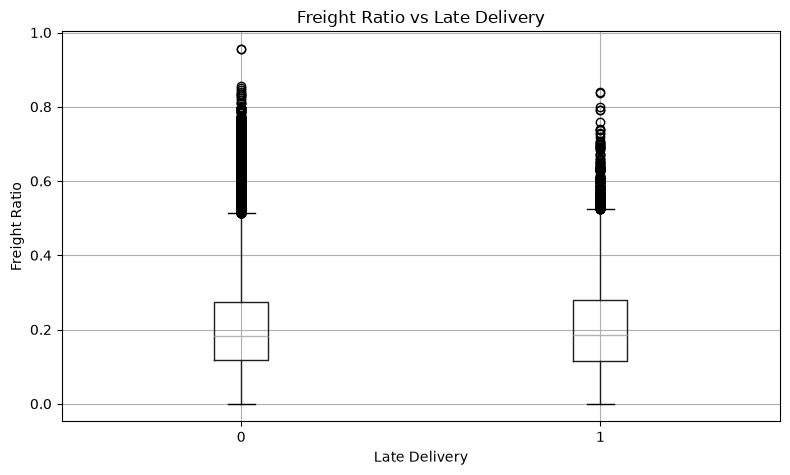

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))

eda_orders.boxplot(
    column="freight_ratio",
    by="late_delivery",
    ax=ax,
)

ax.set_title("Freight Ratio vs Late Delivery")
ax.set_xlabel("Late Delivery")
ax.set_ylabel("Freight Ratio")

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "09_freight_ratio_vs_target.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# 11. Payment EDA

Payments are also one-to-many relative to orders, so payment records are aggregated before merging.

In [36]:
payment_features = (
    payments
    .groupby("order_id")
    .agg(
        payment_records=(
            "payment_sequential",
            "count",
        ),
        payment_value=(
            "payment_value",
            "sum",
        ),
        max_installments=(
            "payment_installments",
            "max",
        ),
        payment_type_count=(
            "payment_type",
            "nunique",
        ),
    )
    .reset_index()
)

assert payment_features["order_id"].is_unique

display(payment_features.head())

,order_id,payment_records,payment_value,max_installments,payment_type_count
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.1900,2,1
1,00018f77f2f0320c557190d7a144bdd3,1,259.8300,3,1
2,000229ec398224ef6ca0657da4fc703e,1,216.8700,5,1
3,00024acbcdf0a6daa1e931b038114c75,1,25.7800,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.0400,3,1


In [37]:
eda_orders = eda_orders.merge(
    payment_features,
    on="order_id",
    how="left",
    validate="one_to_one",
)

assert len(eda_orders) == len(orders)
assert eda_orders["order_id"].is_unique

print("✓ Payment aggregation preserved order-level grain.")

✓ Payment aggregation preserved order-level grain.


## 11.1 Primary payment type

In [38]:
primary_payment = (
    payments
    .sort_values(
        ["order_id", "payment_sequential"]
    )
    .drop_duplicates(
        subset="order_id",
        keep="first",
    )
    [
        [
            "order_id",
            "payment_type",
        ]
    ]
)

assert primary_payment["order_id"].is_unique

eda_orders = eda_orders.merge(
    primary_payment,
    on="order_id",
    how="left",
    validate="one_to_one",
)

assert len(eda_orders) == len(orders)

In [39]:
payment_type_summary = (
    eda_orders
    .groupby("payment_type")
    ["late_delivery"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
    .sort_values(
        "orders",
        ascending=False,
    )
)

display(payment_type_summary)

,orders,late_rate
payment_type,,
credit_card,74293,0.0794
boleto,19177,0.0889
voucher,1498,0.0694
debit_card,1481,0.0783


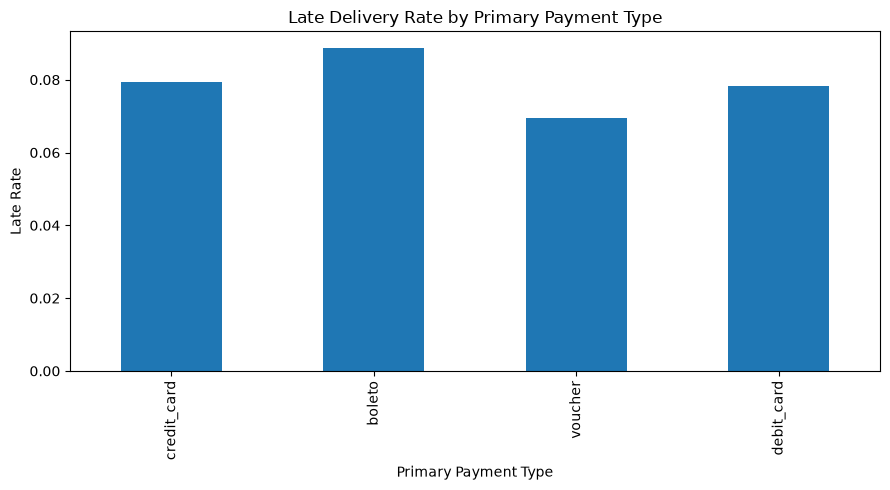

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))

payment_type_summary["late_rate"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Late Delivery Rate by Primary Payment Type")
ax.set_xlabel("Primary Payment Type")
ax.set_ylabel("Late Rate")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "10_payment_type_late_rate.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 11.2 Installments vs target

In [41]:
display(
    eda_orders
    .groupby("late_delivery")
    ["max_installments"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",2.9211,2.7075,0.0000,1.0000,2.0000,4.0000,24.0000
1,"7,822.0000",3.0102,2.7726,1.0000,1.0000,2.0000,4.0000,24.0000


# 12. Product EDA

In [42]:
products_enriched = products.merge(
    category_translation,
    on="product_category_name",
    how="left",
    validate="many_to_one",
)

item_products = order_items.merge(
    products_enriched,
    on="product_id",
    how="left",
    validate="many_to_one",
)

print("Shape:", item_products.shape)
display(item_products.head())

Shape: (112650, 16)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900,cool_stuff,58.0000,598.0000,4.0000,650.0000,28.0000,9.0000,14.0000,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300,pet_shop,56.0000,239.0000,2.0000,"30,000.0000",50.0000,30.0000,40.0000,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700,moveis_decoracao,59.0000,695.0000,2.0000,"3,050.0000",33.0000,13.0000,33.0000,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.9900,12.7900,perfumaria,42.0000,480.0000,1.0000,200.0000,16.0000,10.0000,15.0000,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.9000,18.1400,ferramentas_jardim,59.0000,409.0000,1.0000,"3,750.0000",35.0000,40.0000,30.0000,garden_tools


## 12.1 Product volume

In [43]:
item_products["product_volume_cm3"] = (
    item_products["product_length_cm"]
    * item_products["product_height_cm"]
    * item_products["product_width_cm"]
)

## 12.2 Aggregate product characteristics to order level

In [44]:
product_features = (
    item_products
    .groupby("order_id")
    .agg(
        mean_product_weight_g=(
            "product_weight_g",
            "mean",
        ),
        total_product_weight_g=(
            "product_weight_g",
            "sum",
        ),
        mean_product_volume_cm3=(
            "product_volume_cm3",
            "mean",
        ),
        total_product_volume_cm3=(
            "product_volume_cm3",
            "sum",
        ),
        category_count=(
            "product_category_name",
            "nunique",
        ),
        mean_product_photos=(
            "product_photos_qty",
            "mean",
        ),
    )
    .reset_index()
)

assert product_features["order_id"].is_unique

display(product_features.head())

,order_id,mean_product_weight_g,total_product_weight_g,mean_product_volume_cm3,total_product_volume_cm3,category_count,mean_product_photos
0,00010242fe8c5a6d1ba2dd792cb16214,650.0000,650.0000,"3,528.0000","3,528.0000",1,4.0000
1,00018f77f2f0320c557190d7a144bdd3,"30,000.0000","30,000.0000","60,000.0000","60,000.0000",1,2.0000
2,000229ec398224ef6ca0657da4fc703e,"3,050.0000","3,050.0000","14,157.0000","14,157.0000",1,2.0000
3,00024acbcdf0a6daa1e931b038114c75,200.0000,200.0000,"2,400.0000","2,400.0000",1,1.0000
4,00042b26cf59d7ce69dfabb4e55b4fd9,"3,750.0000","3,750.0000","42,000.0000","42,000.0000",1,1.0000


In [45]:
eda_orders = eda_orders.merge(
    product_features,
    on="order_id",
    how="left",
    validate="one_to_one",
)

assert len(eda_orders) == len(orders)
assert eda_orders["order_id"].is_unique

print("✓ Product aggregation preserved order-level grain.")

✓ Product aggregation preserved order-level grain.


## 12.3 Product characteristics by target

In [46]:
product_characteristics = [
    "mean_product_weight_g",
    "total_product_weight_g",
    "mean_product_volume_cm3",
    "total_product_volume_cm3",
    "category_count",
]

for col in product_characteristics:
    print(f"\n{col}")
    display(
        eda_orders
        .groupby("late_delivery")[col]
        .describe()
    )


mean_product_weight_g


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,611.0000","2,071.7747","3,691.4799",0.0000,300.0000,688.0000,"1,800.0000","40,425.0000"
1,"7,823.0000","2,397.8016","4,292.6271",50.0000,300.0000,750.0000,"2,004.0000","40,425.0000"



total_product_weight_g


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000","2,363.0186","4,713.6320",0.0000,300.0000,750.0000,"2,034.5000","184,400.0000"
1,"7,823.0000","2,652.1460","5,359.4462",50.0000,330.0000,800.0000,"2,300.0000","144,300.0000"



mean_product_volume_cm3


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,611.0000","15,021.2544","22,948.8851",168.0000,"2,816.0000","6,400.0000","18,000.0000","296,208.0000"
1,"7,823.0000","16,640.7130","26,020.6802",352.0000,"2,860.0000","6,615.0000","19,800.0000","269,800.0000"



total_product_volume_cm3


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000","17,226.5676","29,925.4855",0.0000,"2,964.0000","7,245.0000","19,800.0000","1,476,000.0000"
1,"7,823.0000","18,485.4950","32,480.9724",352.0000,"2,964.0000","7,296.0000","20,539.0000","864,000.0000"



category_count


,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",0.9945,0.1488,0.0000,1.0000,1.0000,1.0000,3.0000
1,"7,823.0000",0.9868,0.1307,0.0000,1.0000,1.0000,1.0000,2.0000


## 12.4 Dominant product category per order

For EDA only, define the dominant category as the category with the largest number of item rows within an order.

This is not yet the final production feature definition.

In [47]:
category_counts = (
    item_products
    .groupby(
        [
            "order_id",
            "product_category_name_english",
        ],
        dropna=False,
    )
    .size()
    .rename("item_rows")
    .reset_index()
)

dominant_category = (
    category_counts
    .sort_values(
        ["order_id", "item_rows"],
        ascending=[True, False],
    )
    .drop_duplicates(
        subset="order_id",
        keep="first",
    )
    .rename(
        columns={
            "product_category_name_english": "dominant_category",
        }
    )
    [
        [
            "order_id",
            "dominant_category",
        ]
    ]
)

assert dominant_category["order_id"].is_unique

In [48]:
category_target = (
    eda_orders[
        ["order_id", "late_delivery"]
    ]
    .merge(
        dominant_category,
        on="order_id",
        how="left",
        validate="one_to_one",
    )
    .groupby("dominant_category")
    ["late_delivery"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
    .sort_values(
        "orders",
        ascending=False,
    )
)

display(category_target.head(20))

,orders,late_rate
dominant_category,,
bed_bath_table,9237,0.0877
health_beauty,8621,0.0898
sports_leisure,7475,0.0779
computers_accessories,6519,0.0772
furniture_decor,6203,0.0856
housewares,5670,0.0704
watches_gifts,5451,0.0857
telephony,4070,0.0855
auto,3803,0.0862


# 13. Seller EDA

In [49]:
item_sellers = order_items.merge(
    sellers,
    on="seller_id",
    how="left",
    validate="many_to_one",
)

seller_order_summary = (
    item_sellers
    .groupby("order_id")
    .agg(
        seller_state_count=(
            "seller_state",
            "nunique",
        ),
    )
    .reset_index()
)

assert seller_order_summary["order_id"].is_unique

display(seller_order_summary.head())

,order_id,seller_state_count
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


In [50]:
eda_orders = eda_orders.merge(
    seller_order_summary,
    on="order_id",
    how="left",
    validate="one_to_one",
)

assert len(eda_orders) == len(orders)

## 13.1 Multiple-seller-state orders

In [51]:
display(
    eda_orders
    .groupby("late_delivery")
    ["seller_state_count"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,627.0000",1.0058,0.0768,1.0000,1.0000,1.0000,1.0000,3.0000
1,"7,823.0000",1.0005,0.0226,1.0000,1.0000,1.0000,1.0000,2.0000


# 14. Geolocation Lookup

Raw geolocation is not unique by zip-code prefix.

For EDA, aggregate latitude and longitude to the median coordinate per zip-code prefix before any merge.

In [52]:
geo_lookup = (
    geolocation
    .groupby(
        "geolocation_zip_code_prefix",
        as_index=False,
    )
    .agg(
        latitude=(
            "geolocation_lat",
            "median",
        ),
        longitude=(
            "geolocation_lng",
            "median",
        ),
    )
)

assert (
    geo_lookup[
        "geolocation_zip_code_prefix"
    ].is_unique
)

print("Geo lookup rows:", len(geo_lookup))
display(geo_lookup.head())

Geo lookup rows: 19015


,geolocation_zip_code_prefix,latitude,longitude
0,1001,-23.5504,-46.6340
1,1002,-23.5486,-46.6351
2,1003,-23.5490,-46.6353
3,1004,-23.5495,-46.6348
4,1005,-23.5496,-46.6365


## 14.1 Customer coordinates

In [53]:
customer_geo = customers.merge(
    geo_lookup,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left",
    validate="many_to_one",
)

customer_geo = customer_geo.rename(
    columns={
        "latitude": "customer_lat",
        "longitude": "customer_lng",
    }
)

customer_geo = customer_geo[
    [
        "customer_id",
        "customer_state",
        "customer_lat",
        "customer_lng",
    ]
]

assert customer_geo["customer_id"].is_unique

display(customer_geo.head())

,customer_id,customer_state,customer_lat,customer_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,SP,-20.5021,-47.3968
1,18955e83d337fd6b2def6b18a428ac77,SP,-23.7273,-46.5426
2,4e7b3e00288586ebd08712fdd0374a03,SP,-23.5313,-46.6564
3,b2b6027bc5c5109e529d4dc6358b12c3,SP,-23.4974,-46.1823
4,4f2d8ab171c80ec8364f7c12e35b23ad,SP,-22.9733,-47.1415


## 14.2 Seller coordinates

In [54]:
seller_geo = sellers.merge(
    geo_lookup,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left",
    validate="many_to_one",
)

seller_geo = seller_geo.rename(
    columns={
        "latitude": "seller_lat",
        "longitude": "seller_lng",
    }
)

seller_geo = seller_geo[
    [
        "seller_id",
        "seller_state",
        "seller_lat",
        "seller_lng",
    ]
]

assert seller_geo["seller_id"].is_unique

display(seller_geo.head())

,seller_id,seller_state,seller_lat,seller_lng
0,3442f8959a84dea7ee197c632cb2df15,SP,-22.8946,-47.0624
1,d1b65fc7debc3361ea86b5f14c68d2e2,SP,-22.3824,-46.9476
2,ce3ad9de960102d0677a81f5d0bb7b2d,RJ,-22.9096,-43.1768
3,c0f3eea2e14555b6faeea3dd58c1b1c3,SP,-23.6575,-46.6124
4,51a04a8a6bdcb23deccc82b0b80742cf,SP,-22.9644,-46.5351


# 15. Customer–Seller Distance

Because one order may contain multiple sellers, compute seller-to-customer distance at item/seller level first, then aggregate the distances back to one row per order.

In [55]:
def haversine_distance(
    lat1: pd.Series,
    lon1: pd.Series,
    lat2: pd.Series,
    lon2: pd.Series,
) -> pd.Series:
    earth_radius_km = 6371.0088

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1_rad)
        * np.cos(lat2_rad)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(
        np.sqrt(a)
    )

    return earth_radius_km * c

## 15.1 Attach customer coordinates to eligible orders

In [56]:
order_customer_geo = (
    orders[
        [
            "order_id",
            "customer_id",
        ]
    ]
    .merge(
        customer_geo,
        on="customer_id",
        how="left",
        validate="many_to_one",
    )
)

assert order_customer_geo["order_id"].is_unique

display(order_customer_geo.head())

,order_id,customer_id,customer_state,customer_lat,customer_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP,-23.5762,-46.5873
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA,-12.1267,-45.0082
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO,-16.7445,-48.5146
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,RN,-5.7746,-35.2739
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,SP,-23.6753,-46.5151


## 15.2 Attach seller coordinates at order-item level

In [57]:
distance_rows = (
    order_items
    [
        [
            "order_id",
            "seller_id",
        ]
    ]
    .merge(
        order_customer_geo[
            [
                "order_id",
                "customer_lat",
                "customer_lng",
                "customer_state",
            ]
        ],
        on="order_id",
        how="inner",
        validate="many_to_one",
    )
    .merge(
        seller_geo,
        on="seller_id",
        how="left",
        validate="many_to_one",
    )
)

print("Distance rows:", len(distance_rows))
display(distance_rows.head())

Distance rows: 110167


,order_id,seller_id,customer_lat,customer_lng,customer_state,seller_state,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,-21.7628,-41.3106,RJ,SP,-22.4984,-44.1253
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,-20.2057,-50.9269,SP,SP,-23.5643,-46.5190
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,-19.8704,-44.5944,MG,MG,-22.2716,-46.1656
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,-23.1043,-46.5956,SP,SP,-20.5550,-47.3877
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,-23.2455,-46.8252,SP,PR,-22.9304,-53.1364


## 15.3 Same-state indicator at seller row level

In [58]:
distance_rows["seller_customer_same_state"] = (
    distance_rows["seller_state"]
    ==
    distance_rows["customer_state"]
).astype("int8")

## 15.4 Haversine distance

In [59]:
distance_rows["seller_customer_distance_km"] = (
    haversine_distance(
        distance_rows["customer_lat"],
        distance_rows["customer_lng"],
        distance_rows["seller_lat"],
        distance_rows["seller_lng"],
    )
)

display(
    distance_rows[
        "seller_customer_distance_km"
    ].describe()
)

count   109,631.0000
mean        596.2348
std         588.9493
min           0.0000
25%         184.2431
50%         431.9463
75%         791.1391
max       8,677.8716
Name: seller_customer_distance_km, dtype: float64

## 15.5 Aggregate distance features to order level

In [60]:
distance_features = (
    distance_rows
    .groupby("order_id")
    .agg(
        mean_distance_km=(
            "seller_customer_distance_km",
            "mean",
        ),
        max_distance_km=(
            "seller_customer_distance_km",
            "max",
        ),
        min_distance_km=(
            "seller_customer_distance_km",
            "min",
        ),
        all_sellers_same_state=(
            "seller_customer_same_state",
            "min",
        ),
        same_state_seller_share=(
            "seller_customer_same_state",
            "mean",
        ),
    )
    .reset_index()
)

assert distance_features["order_id"].is_unique

display(distance_features.head())

,order_id,mean_distance_km,max_distance_km,min_distance_km,all_sellers_same_state,same_state_seller_share
0,00010242fe8c5a6d1ba2dd792cb16214,301.2296,301.2296,301.2296,0,0.0000
1,00018f77f2f0320c557190d7a144bdd3,588.4049,588.4049,588.4049,1,1.0000
2,000229ec398224ef6ca0657da4fc703e,312.8355,312.8355,312.8355,1,1.0000
3,00024acbcdf0a6daa1e931b038114c75,295.0329,295.0329,295.0329,1,1.0000
4,00042b26cf59d7ce69dfabb4e55b4fd9,646.4694,646.4694,646.4694,0,0.0000


In [61]:
eda_orders = eda_orders.merge(
    distance_features,
    on="order_id",
    how="left",
    validate="one_to_one",
)

assert len(eda_orders) == len(orders)
assert eda_orders["order_id"].is_unique

print("✓ Distance aggregation preserved order-level grain.")

✓ Distance aggregation preserved order-level grain.


## 15.6 Distance vs target

In [62]:
display(
    eda_orders
    .groupby("late_delivery")
    ["mean_distance_km"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
late_delivery,,,,,,,,
0,"88,201.0000",588.5514,583.2106,0.0000,176.1568,426.6877,783.3397,"8,032.9408"
1,"7,773.0000",739.1050,688.7993,0.0000,294.6945,511.9018,925.4032,"8,677.8716"


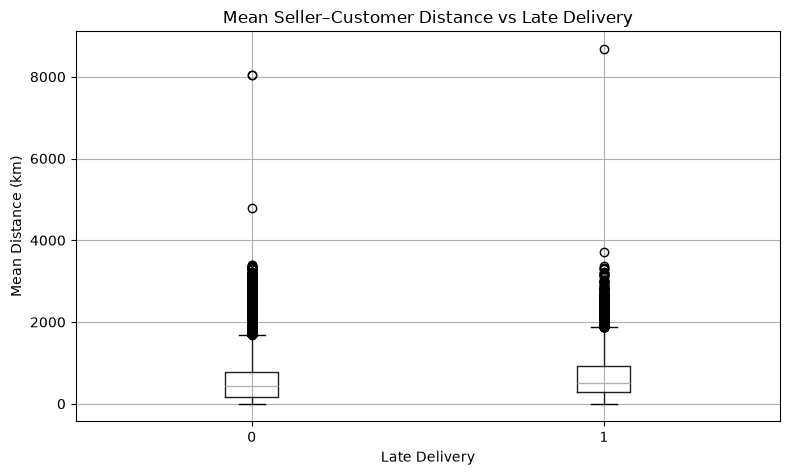

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

eda_orders.boxplot(
    column="mean_distance_km",
    by="late_delivery",
    ax=ax,
)

ax.set_title("Mean Seller–Customer Distance vs Late Delivery")
ax.set_xlabel("Late Delivery")
ax.set_ylabel("Mean Distance (km)")

plt.suptitle("")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "11_distance_vs_target.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 15.7 Same-state delivery risk

In [64]:
same_state_summary = (
    eda_orders
    .groupby("all_sellers_same_state")
    ["late_delivery"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "orders",
            "mean": "late_rate",
        }
    )
)

display(same_state_summary)

,orders,late_rate
all_sellers_same_state,,
0,61885,0.0925
1,34565,0.0608


# 16. Candidate Numeric Signals

This section compares candidate numeric variables with the target.

It is exploratory only and does **not** select the final feature set.

Because the features use different units and scales, absolute differences between class means must **not** be interpreted as feature-importance rankings.


This section compares candidate numeric variables with the target.

It is exploratory only. It does not select the final feature set.

In [65]:
candidate_numeric_features = [
    "promised_delivery_days",
    "item_count",
    "unique_products",
    "seller_count",
    "total_price",
    "total_freight",
    "freight_ratio",
    "payment_value",
    "max_installments",
    "mean_product_weight_g",
    "total_product_weight_g",
    "mean_product_volume_cm3",
    "total_product_volume_cm3",
    "category_count",
    "mean_distance_km",
    "max_distance_km",
    "same_state_seller_share",
]

available_numeric_features = [
    col
    for col in candidate_numeric_features
    if col in eda_orders.columns
]

numeric_signal_summary = []

for col in available_numeric_features:
    grouped = (
        eda_orders
        .groupby("late_delivery")[col]
        .agg(["count", "mean", "median", "std"])
    )

    late_mean = grouped.loc[1, "mean"] if 1 in grouped.index else np.nan
    on_time_mean = grouped.loc[0, "mean"] if 0 in grouped.index else np.nan

    numeric_signal_summary.append(
        {
            "feature": col,
            "on_time_mean": on_time_mean,
            "late_mean": late_mean,
            "mean_difference_late_minus_on_time": (
                late_mean - on_time_mean
            ),
            "missing": int(eda_orders[col].isna().sum()),
        }
    )

numeric_signal_summary = (
    pd.DataFrame(numeric_signal_summary)
    .sort_values(
        "mean_difference_late_minus_on_time",
        key=lambda s: s.abs(),
        ascending=False,
    )
)

display(numeric_signal_summary)

,feature,on_time_mean,late_mean,mean_difference_late_minus_on_time,missing
11,mean_product_volume_cm3,"15,021.2544","16,640.7130","1,619.4586",16
12,total_product_volume_cm3,"17,226.5676","18,485.4950","1,258.9273",0
9,mean_product_weight_g,"2,071.7747","2,397.8016",326.0269,16
10,total_product_weight_g,"2,363.0186","2,652.1460",289.1274,0
14,mean_distance_km,588.5514,739.1050,150.5536,476
15,max_distance_km,589.9961,739.2253,149.2292,476
7,payment_value,158.7235,172.7209,13.9975,1
4,total_price,136.0690,148.0696,12.0006,0
0,promised_delivery_days,23.4709,21.4641,-2.0068,0
5,total_freight,22.6243,24.6233,1.9989,0


# 17. Missingness After EDA Joins

In [66]:
eda_missing_summary = (
    eda_orders
    .isna()
    .sum()
    .rename("missing")
    .to_frame()
)

eda_missing_summary["missing_pct"] = (
    eda_missing_summary["missing"]
    / len(eda_orders)
    * 100
)

eda_missing_summary = (
    eda_missing_summary[
        eda_missing_summary["missing"] > 0
    ]
    .sort_values(
        "missing_pct",
        ascending=False,
    )
)

display(eda_missing_summary)

,missing,missing_pct
mean_product_photos,1331,1.3800
max_distance_km,476,0.4935
min_distance_km,476,0.4935
mean_distance_km,476,0.4935
mean_product_weight_g,16,0.0166
mean_product_volume_cm3,16,0.0166
payment_records,1,0.0010
order_delivered_carrier_date,1,0.0010
max_installments,1,0.0010
payment_value,1,0.0010


Missing values created by relational joins must be understood before Phase 3 decides on imputation or missing indicators.

Do not apply blanket `fillna(0)` in EDA.

# 18. Leakage Review

In [67]:
FORBIDDEN_MODEL_FEATURES = {
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "delivery_delay_days",
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "review_creation_date",
    "review_answer_timestamp",
}

present_forbidden_columns = (
    FORBIDDEN_MODEL_FEATURES
    .intersection(eda_orders.columns)
)

print("Forbidden columns currently present in EDA table:")
print(present_forbidden_columns)

Forbidden columns currently present in EDA table:
{'delivery_delay_days', 'order_delivered_carrier_date', 'order_delivered_customer_date'}


It is acceptable for outcome-related columns such as `order_delivered_customer_date` and `delivery_delay_days` to remain in the **EDA table** for target analysis.

They must be explicitly excluded when the final feature matrix `X` is constructed in Phase 3.

# 19. Final Grain Validation

In [68]:
assert len(eda_orders) == len(orders)
assert eda_orders["order_id"].is_unique

print(
    f"✓ EDA table preserves final modeling grain: "
    f"{len(eda_orders):,} unique orders."
)


✓ EDA table preserves final modeling grain: 96,450 unique orders.


# 20. Export EDA Summaries

In [69]:
monthly_late_rate.to_csv(
    METRICS_DIR / "eda_monthly_late_rate.csv"
)

customer_state_summary.to_csv(
    METRICS_DIR / "eda_customer_state_late_rate.csv"
)

payment_type_summary.to_csv(
    METRICS_DIR / "eda_payment_type_late_rate.csv"
)

numeric_signal_summary.to_csv(
    METRICS_DIR / "eda_numeric_signal_summary.csv",
    index=False,
)

eda_missing_summary.to_csv(
    METRICS_DIR / "eda_missing_summary.csv"
)

print("✓ EDA summary reports exported.")

✓ EDA summary reports exported.


# 21. Conclusions

Update the numeric statements below from the current Run All outputs.

## Target

The finalized modeling population is loaded from:

`data/interim/orders_cleaned.parquet`

The upstream cleaning pipeline excludes invalid orders where:

`order_estimated_delivery_date < order_approved_at`

The exact final population size and target distribution must be taken from the current notebook outputs rather than hard-coded.

The target remains imbalanced, so Accuracy will not be the primary model-selection metric.

## Temporal patterns

Evaluate monthly, weekday, and hourly late-delivery patterns. Material monthly variation supports chronological validation.

## Promise window

`promised_delivery_days` is defined as:

`order_estimated_delivery_date - order_approved_at`

The cleaned population must satisfy:

`promised_delivery_days >= 0`

Shorter promise windows remain an important candidate signal to evaluate.

## Geography

Customer state, seller–customer distance, and same-state fulfillment are important candidate feature groups.

## Order and product characteristics

Retain order value, freight, item/seller counts, product weight, product volume, and category-related aggregates as initial candidate features.

## Payment

Payment type and installment-related variables may provide incremental predictive value.

## Missingness

Handle low-level missingness during preprocessing rather than automatically dropping otherwise valid observations.

## Leakage

The following columns may appear in EDA but must never enter the final model feature matrix:

- `order_delivered_carrier_date`
- `order_delivered_customer_date`
- `delivery_delay_days`
- review-related information

## Data integrity

Every relational aggregation must preserve:

**1 row = 1 order**

The notebook validates the row count dynamically against the current cleaned population.

## Next step

Proceed to **Phase 3 — Feature Engineering & Dataset Design**:

1. define the final feature contract;
2. implement reusable aggregation functions;
3. enforce leakage rules;
4. construct the order-level feature table;
5. define chronological train/validation/test splits;
6. build the preprocessing pipeline.


# 22. Candidate Feature Checklist for Phase 3

Based on EDA, evaluate the following candidate features before finalizing the feature dataset.

### Time

- purchase hour
- purchase weekday
- purchase month
- weekend indicator
- promised delivery days

### Order

- item count
- unique products
- seller count
- total price
- total freight
- freight ratio
- mean/max item price

### Product

- total/mean weight
- total/mean volume
- category count
- dominant category

### Payment

- primary payment type
- payment record count
- maximum installments
- payment type count
- total payment value

### Geography

- customer state
- seller state aggregation
- mean/max seller-customer distance
- same-state seller share

> Final inclusion must depend on feature availability at `order_approved_at`, leakage checks, missingness, stability, and modeling value.